In [28]:
#type: ignore
import ee
import geemap
import eemont

In [29]:
ee.Authenticate()
ee.Initialize(project="tidop-439510")

In [30]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)
geometry = ee.Geometry.Polygon(
    [
        [
            [-4.80653103999193, 40.595495845319725],
            [-4.590237705030993, 40.595495845319725],
            [-4.590237705030993, 40.755109422249504],
            [-4.80653103999193, 40.755109422249504],
            [-4.80653103999193, 40.595495845319725],
        ]
    ]
)
Map.centerObject(geometry, 12)
Map.addLayer(geometry, {"color": "blue"}, "Geometry Ávila")
Map

Map(center=[40.67532124163311, -4.6983843725096985], controls=(WidgetControl(options=['position', 'transparent…

In [54]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)

bands_land9 = ["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7"]
bands_sen2 = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B11", "B12"]

img_land9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterDate("2025-01-01", "2025-12-31")
    .filter(ee.Filter.lt("CLOUD_COVER", 20))
    .filterBounds(geometry)
    .scale()
    .median()
    .clip(geometry)
    .select(bands_land9)
)

img_sen2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2025-01-01", "2025-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .filterBounds(geometry)
    .preprocess()
    .median()
    .clip(geometry)
    .select(bands_sen2)
)

vis_params_land9 = {"min": 0.0, "max": 0.5, "gamma": 1.4, "bands": ["SR_B6", "SR_B5", "SR_B4"]}

vis_params_sen2 = {"min": 0.0, "max": 0.5, "gamma": 1.4, "bands": ["B11", "B8", "B2"]}

Map.centerObject(geometry, 12)
Map.addLayer(img_land9, vis_params_land9, "Landsat 9 Image median")
Map.addLayer(img_sen2, vis_params_sen2, "Sentinel-2 Image median")
Map

Map(center=[40.67532124163311, -4.6983843725096985], controls=(WidgetControl(options=['position', 'transparent…

## **Machine Learning con Google Earth Engine - Unsupervised Classification**

### **Sampling en Clasificación No Supervisada**

En clasificación no supervisada, el *sampling* consiste en extraer píxeles sin etiquetas temáticas para identificar patrones espectrales automáticamente.

Una imagen multiespectral puede representarse como:

$$I(x,y)=\{b_1,b_2,b_3,\dots,b_n\}$$

Cada píxel corresponde a un vector espectral:

$$
x_i=
\begin{bmatrix}
b_1\\
b_2\\
b_3\\
\vdots\\
b_n
\end{bmatrix}
$$

El conjunto de muestras se define como:

$$D=\{x_1,x_2,x_3,\dots,x_m\}$$

In [56]:
training_kmeans_land = img_land9.sample(
    region=geometry, 
    scale=30, 
    numPixels=10000
)

### **K-Means Clustering**

K-Means es un algoritmo de aprendizaje no supervisado que agrupa píxeles con características espectrales similares en $k$ clusters. El algoritmo se ejecuta de manera iterativa hasta converger en una solución estable.

- **1. Datos de entrada**: Los píxeles se representan como puntos en un espacio multiespectral. Tenemos un conjunto de muestras:

$$D=\{x_1,x_2,x_3,\dots,x_m\}$$

- **2. Inicialización de centroides**: Se seleccionan aleatoriamente $k$ centroides iniciales:

$$\mu_1,\mu_2,\dots,\mu_k$$

- **3. Asignación de píxeles**: Cada píxel se asigna al centroide más cercano utilizando distancia euclidiana. Donde: $x_i$ es el  valor espectral del píxel, $\mu_i$ es el valor espectral del centroide y $n$ es el número de bandas espectrales


$$
d(x,\mu)=\sqrt{\sum_{i=1}^{n}(x_i-\mu_i)^2}
$$

- **4. Actualización de centroides**: Se recalcula cada centroide como el promedio de los píxeles de su cluster:

$$
\mu_i=\frac{1}{|C_i|}\sum_{x_j \in C_i}x_j
$$

Se repiten los pasos 3 y 4 hasta que los centroides no cambien significativamente.

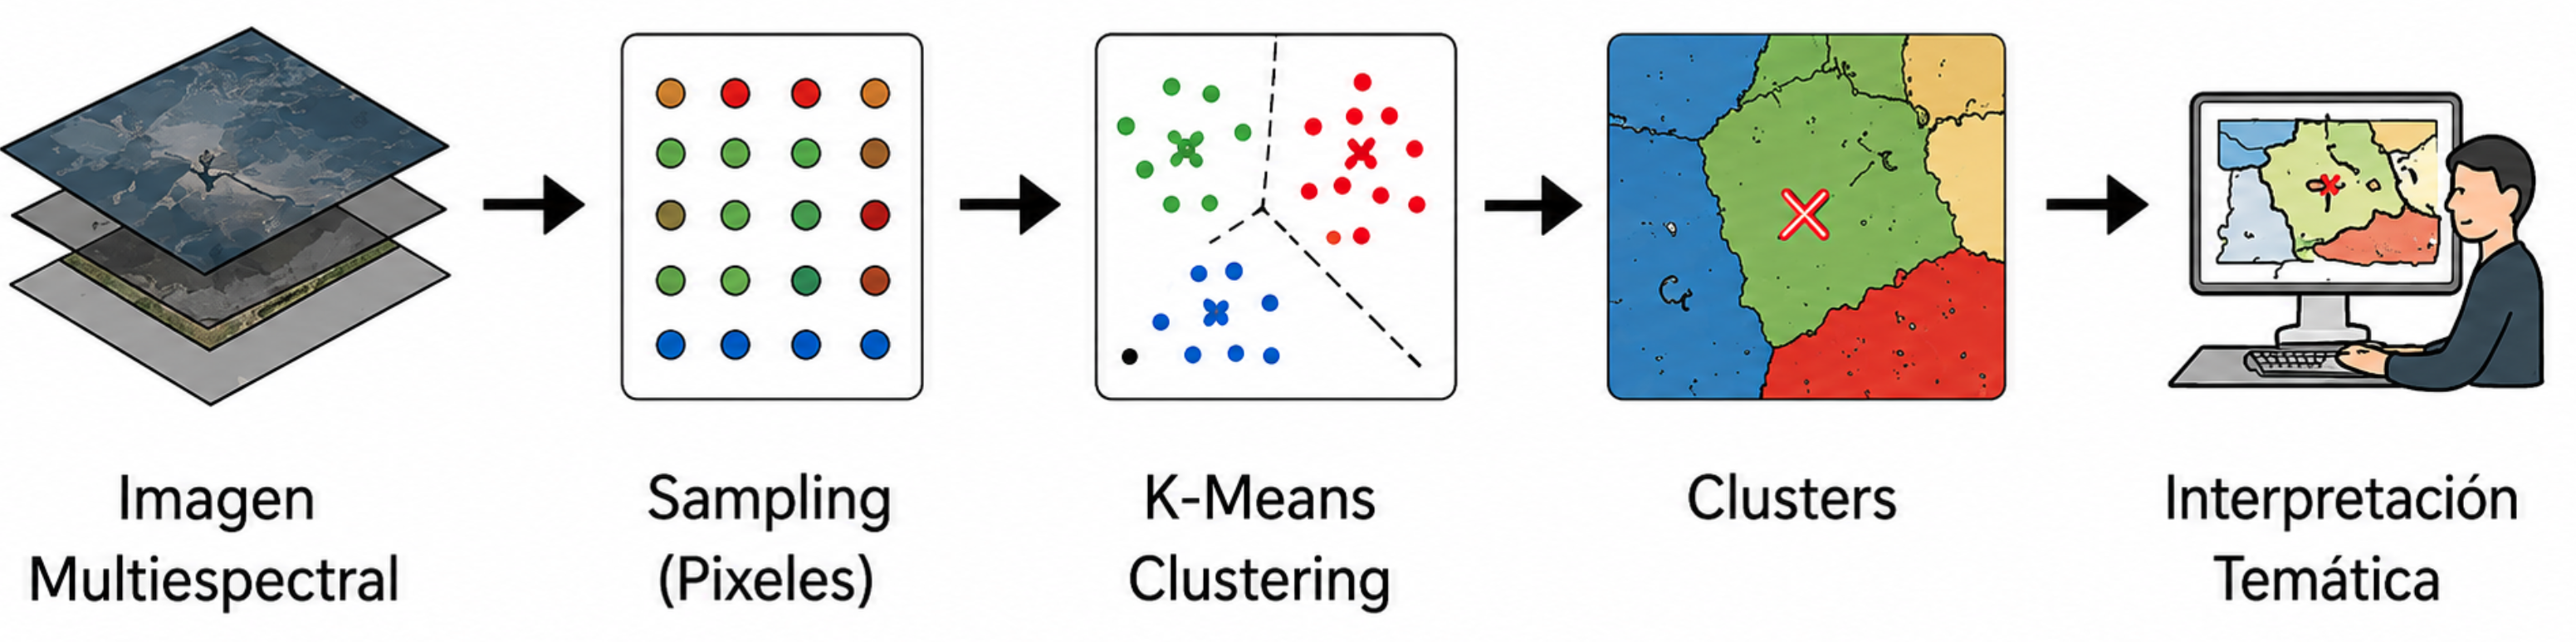

In [57]:
kmeans = ee.Clusterer.wekaKMeans(nClusters=6).train(training_kmeans_land)
kmeans_result = img_land9.cluster(kmeans)

### **X-Means Clustering**

X-Means es una extensión del algoritmo K-Means que permite determinar automáticamente el número óptimo de clusters dentro de un rango definido por el usuario. El algoritmo comienza con un número inicial de clusters y evalúa iterativamente si los grupos deben dividirse para mejorar la representación espectral de los datos.

- **1. Datos de entrada**: Los píxeles se representan como puntos en un espacio multiespectral. Tenemos un conjunto de muestras:

$$D=\{x_1,x_2,x_3,\dots,x_m\}$$

- **2. Definición del rango de clusters**: El algoritmo evalúa automáticamente el número óptimo de clusters dentro del rango:

$$k_{min}=4 \quad ; \quad k_{max}=5$$

donde:

- $k_{min}$ → número mínimo de clusters
- $k_{max}$ → número máximo de clusters

- **3. Inicialización de centroides**: Se generan centroides iniciales para comenzar el proceso de agrupamiento:

$$\mu_1,\mu_2,\dots,\mu_k$$

- **4. Asignación de píxeles**: Cada píxel se asigna al centroide más cercano utilizando distancia euclidiana. Donde: $x_i$ es el valor espectral del píxel, $\mu_i$ es el valor espectral del centroide y $n$ es el número de bandas espectrales.

$$
d(x,\mu)=\sqrt{\sum_{i=1}^{n}(x_i-\mu_i)^2}
$$

- **5. Evaluación de nuevos clusters**: X-Means analiza si dividir un cluster mejora la representación estadística de los datos utilizando criterios como BIC (*Bayesian Information Criterion*).

$$
BIC = L - \frac{p}{2}\ln(N)
$$

donde:

- $L$ → verosimilitud del modelo
- $p$ → número de parámetros
- $N$ → número de muestras

- **6. Actualización de centroides**: Los centroides se recalculan utilizando el promedio espectral de los píxeles asignados:

$$
\mu_i=\frac{1}{|C_i|}\sum_{x_j \in C_i}x_j
$$

Se repiten los pasos de asignación y evaluación hasta encontrar el número óptimo de clusters dentro del rango especificado.


In [58]:
xmeans = ee.Clusterer.wekaXMeans(4,5).train(training_kmeans_land)
xmeans_result = img_land9.cluster(xmeans)

### **LVQ Clustering (Learning Vector Quantization)**

LVQ (*Learning Vector Quantization*) es un algoritmo de clasificación basado en prototipos que agrupa píxeles utilizando vectores representativos llamados centroides o neuronas. El algoritmo ajusta iterativamente la posición de estos centroides para representar mejor las características espectrales de los datos.

- **1. Datos de entrada**: Los píxeles se representan como puntos en un espacio multiespectral. Tenemos un conjunto de muestras:

$$D=\{x_1,x_2,x_3,\dots,x_m\}$$

- **2. Definición del número de centroides**: El algoritmo inicializa un número fijo de centroides:

$$k=5$$

donde:

- $k$ representa el número de clusters o prototipos espectrales.

- **3. Inicialización de centroides**: Se generan centroides iniciales:

$$\mu_1,\mu_2,\dots,\mu_k$$

- **4. Asignación de píxeles**: Cada píxel se asigna al centroide más cercano utilizando distancia euclidiana. Donde: $x_i$ es el valor espectral del píxel, $\mu_i$ es el valor espectral del centroide y $n$ es el número de bandas espectrales.

$$
d(x,\mu)=\sqrt{\sum_{i=1}^{n}(x_i-\mu_i)^2}
$$

- **5. Actualización de centroides**: Los centroides se ajustan iterativamente acercándose a los píxeles asignados:

$$
\mu_i^{(t+1)}=\mu_i^{(t)}+\alpha(x_j-\mu_i^{(t)})
$$

donde:

- $\alpha$ representa la tasa de aprendizaje
- $t$ representa la iteración actual
- $x_j$ representa el píxel asignado

Se repiten los pasos de asignación y actualización hasta que los centroides converjan en una solución estable.


In [59]:
lvq = ee.Clusterer.wekaLVQ(5).train(training_kmeans_land)
lvq_result = img_land9.cluster(lvq)

In [67]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)
palette = ["gray", "purple", "green", "blue", "pink"]

cluster_vis = {
    "min": 0,
    "max": 4,
    "palette": palette
}
Map.centerObject(geometry, 12)
Map.addLayer(kmeans_result, cluster_vis, "KMeans Landsat 9")
Map.addLayer(xmeans_result, cluster_vis, "XMeans Landsat 9")
Map.addLayer(lvq_result, cluster_vis, "LVQ Landsat 9")
Map

Map(center=[40.67532124163311, -4.6983843725096985], controls=(WidgetControl(options=['position', 'transparent…

### **MSI de Sentinel-2: instrumento multiespectral**

In [ ]:
training_kmeans = img_sen2.sample(
    region=geometry, 
    scale=10, 
    numPixels=10000, # Controla la cantidad aproximada de píxeles extraídos aleatoriamente
    seed=42, # Permite que el muestreo aleatorio genere siempre los mismos píxeles
    geometries=False
)

clusterer = ee.Clusterer.wekaKMeans(nClusters=6).train(training_kmeans)

result = img_sen2.cluster(clusterer)

In [73]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)
Map.centerObject(geometry, 12)
palette = [
    "#5a6063",
    "#33a02c",
    "#e31a1c",
    "#2151d4",
    "#6a3d9a",
    "#b15928"
]

cluster_vis = {
    "min": 0,
    "max": 5,
    "palette": palette
}

Map.addLayer(result, cluster_vis, "Clasificación K-Means")
Map

Map(center=[40.67532124163311, -4.6983843725096985], controls=(WidgetControl(options=['position', 'transparent…

## **Machine Learning con Google Earth Engine - Supervised Classification**

### **Sampling en Clasificación Supervisada**

En clasificación supervisada, el **sampling** consiste en extraer píxeles junto con sus etiquetas temáticas para entrenar un modelo de Machine Learning.

Una imagen multiespectral puede representarse como:

$$I(x,y)=\{b_1,b_2,b_3,\dots,b_n\}$$

Cada píxel corresponde a un vector espectral:

$$
x_i=
\begin{bmatrix}
b_1\\
b_2\\
b_3\\
\vdots\\
b_n
\end{bmatrix}
$$

Cada muestra posee además una etiqueta temática asociada:

$$y_i \in \{Vegetación, Agua, Urbano, Suelo\}$$

El conjunto de entrenamiento se define como:

$$D=\{(x_1,y_1),(x_2,y_2),\dots,(x_m,y_m)\}$$

donde:

- $x_i$ representa el vector espectral del píxel
- $y_i$ representa la clase conocida
- $m$ representa el número total de muestras

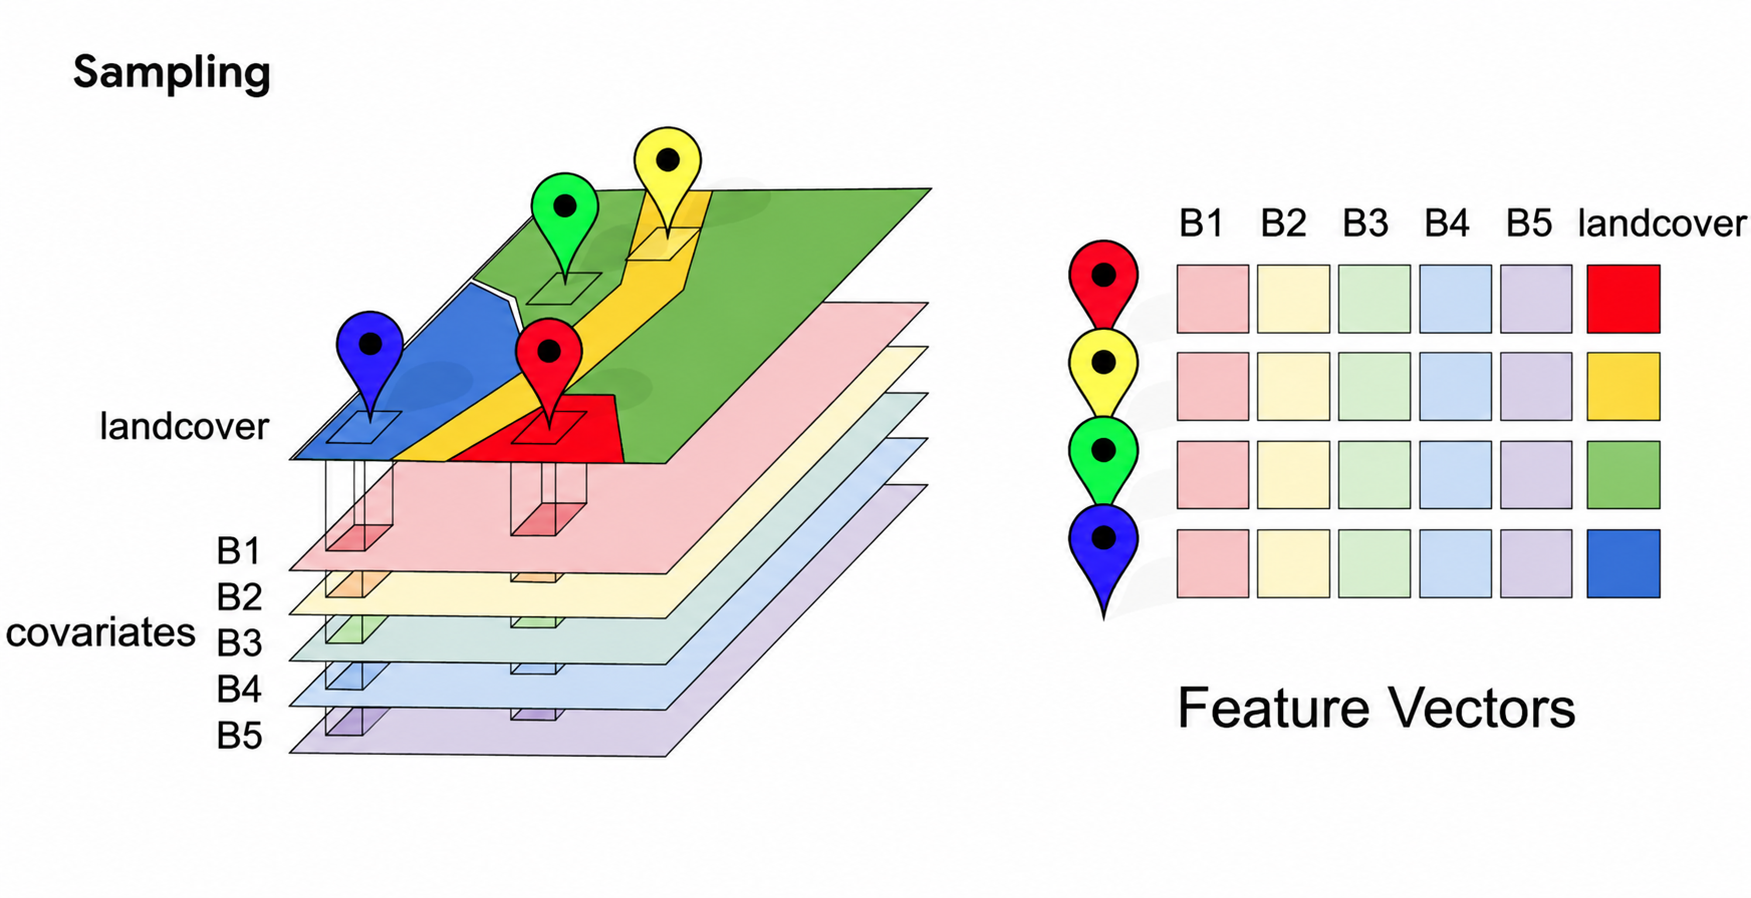

In [75]:
urban_geometry = ee.Geometry.Polygon(
    [
        [
            [-4.679764, 40.661037],
            [-4.682941, 40.660777],
            [-4.682597, 40.659735],
            [-4.680579, 40.659768],
            [-4.679678, 40.660386],
            [-4.679764, 40.661037],
        ]
    ]
)

water_geometry = ee.Geometry.Polygon(
    [
        [
            [-4.698909, 40.724977],
            [-4.702472, 40.724651],
            [-4.70127, 40.7227],
            [-4.700282, 40.720553],
            [-4.701227, 40.719643],
            [-4.700025, 40.718309],
            [-4.699209, 40.716748],
            [-4.696333, 40.71613],
            [-4.694358, 40.714959],
            [-4.692231, 40.713684],
            [-4.689054, 40.712774],
            [-4.686307, 40.713815],
            [-4.689054, 40.715961],
            [-4.693777, 40.717718],
            [-4.696009, 40.720971],
            [-4.698327, 40.724223],
            [-4.698909, 40.724977],
        ]
    ]
)
land_geometry = ee.Geometry.Polygon(
    [
        [
            [-4.719079, 40.704809],
            [-4.722814, 40.705297],
            [-4.724403, 40.704581],
            [-4.725691, 40.703247],
            [-4.726936, 40.702727],
            [-4.727021, 40.701621],
            [-4.725605, 40.701491],
            [-4.724231, 40.702597],
            [-4.721955, 40.703117],
            [-4.720152, 40.703052],
            [-4.718435, 40.703085],
            [-4.718006, 40.703931],
            [-4.719079, 40.704809],
        ]
    ]
)
vegetation_geometry = ee.Geometry.Polygon(
    [
        [
            [-4.702592, 40.718198],
            [-4.703837, 40.717921],
            [-4.704974, 40.717677],
            [-4.706112, 40.717417],
            [-4.707142, 40.717043],
            [-4.707421, 40.716832],
            [-4.705854, 40.716685],
            [-4.70521, 40.716555],
            [-4.704545, 40.716523],
            [-4.703729, 40.716572],
            [-4.702613, 40.716946],
            [-4.701475, 40.717173],
            [-4.701067, 40.717499],
            [-4.701411, 40.717986],
            [-4.702098, 40.718279],
            [-4.702592, 40.718198],
        ]
    ]
)

In [77]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)

classes = {
    0: "urban",
    1: "water",
    2: "bareland",
    3: "vegetation"
}

urban = ee.Feature(urban_geometry, {"class": 0})
water = ee.Feature(water_geometry, {"class": 1})
land = ee.Feature(land_geometry, {"class": 2})
vegetation = ee.Feature(vegetation_geometry, {"class": 3})

training_fc = ee.FeatureCollection([urban, water, land, vegetation])

Map.centerObject(geometry, 12)
Map.addLayer(img_sen2, vis_params_sen2, "Sentinel-2 Image median")
Map.addLayer(urban, {"color": "red"}, "Urban")
Map.addLayer(water, {"color": "blue"}, "Water")
Map.addLayer(land, {"color": "orange"}, "Bareland")
Map.addLayer(vegetation, {"color": "green"}, "Vegetation")
Map.addLayer(training_fc, {"color": "red"}, "Training Samples")
Map

Map(center=[40.67532124163311, -4.6983843725096985], controls=(WidgetControl(options=['position', 'transparent…

In [79]:
training = img_sen2.sampleRegions(
    collection=training_fc,
    properties=["class"],
    scale=10,
    geometries=True
)

print("Número de muestras de entrenamiento:", training.size().getInfo())

Número de muestras de entrenamiento: 11114


### **Random Forest Classification**

Random Forest es un algoritmo de aprendizaje supervisado que clasifica píxeles utilizando múltiples árboles de decisión.  
Cada árbol aprende patrones espectrales diferentes y la clasificación final se obtiene mediante votación mayoritaria.

##### **1. Datos de Entrada**

Los píxeles se representan mediante vectores espectrales junto con su clase temática conocida.

Conjunto de entrenamiento:

$$
D=\{(x_1,y_1),(x_2,y_2),\dots,(x_m,y_m)\}
$$

donde:

- $x_i$ representa el vector espectral del píxel.
- $y_i$ representa la clase temática conocida.
- $m$ representa el número total de muestras.

Cada píxel puede representarse como:

$$
x_i=
\begin{bmatrix}
b_1\\
b_2\\
b_3\\
\vdots\\
b_n
\end{bmatrix}
$$

donde:

- $b_n$ representa una banda espectral.
- $n$ representa el número total de bandas.

##### **2. Construcción de Árboles**

Se generan aleatoriamente múltiples árboles de decisión utilizando subconjuntos de muestras y bandas espectrales:

$$
T_1,T_2,T_3,\dots,T_k
$$

donde:

- $T_k$ representa el árbol número $k$.
- $k$ representa el número total de árboles del bosque.

Cada árbol aprende reglas espectrales para separar clases temáticas.


##### **3. Clasificación Individual**

Cada árbol realiza una predicción independiente para el píxel de entrada:

$$
T_k(x_i)=c_j
$$

donde:

- $x_i$ representa el vector espectral del píxel.
- $c_j$ representa la clase predicha por el árbol.


##### **4. Votación Mayoritaria**

La clasificación final se obtiene mediante la clase más votada entre todos los árboles:

$$
\hat{y}=\operatorname{mode}\{T_1(x),T_2(x),\dots,T_k(x)\}
$$

donde:

- $\hat{y}$ representa la clase final predicha.
- $\operatorname{mode}$ representa la clase con mayor número de votos.

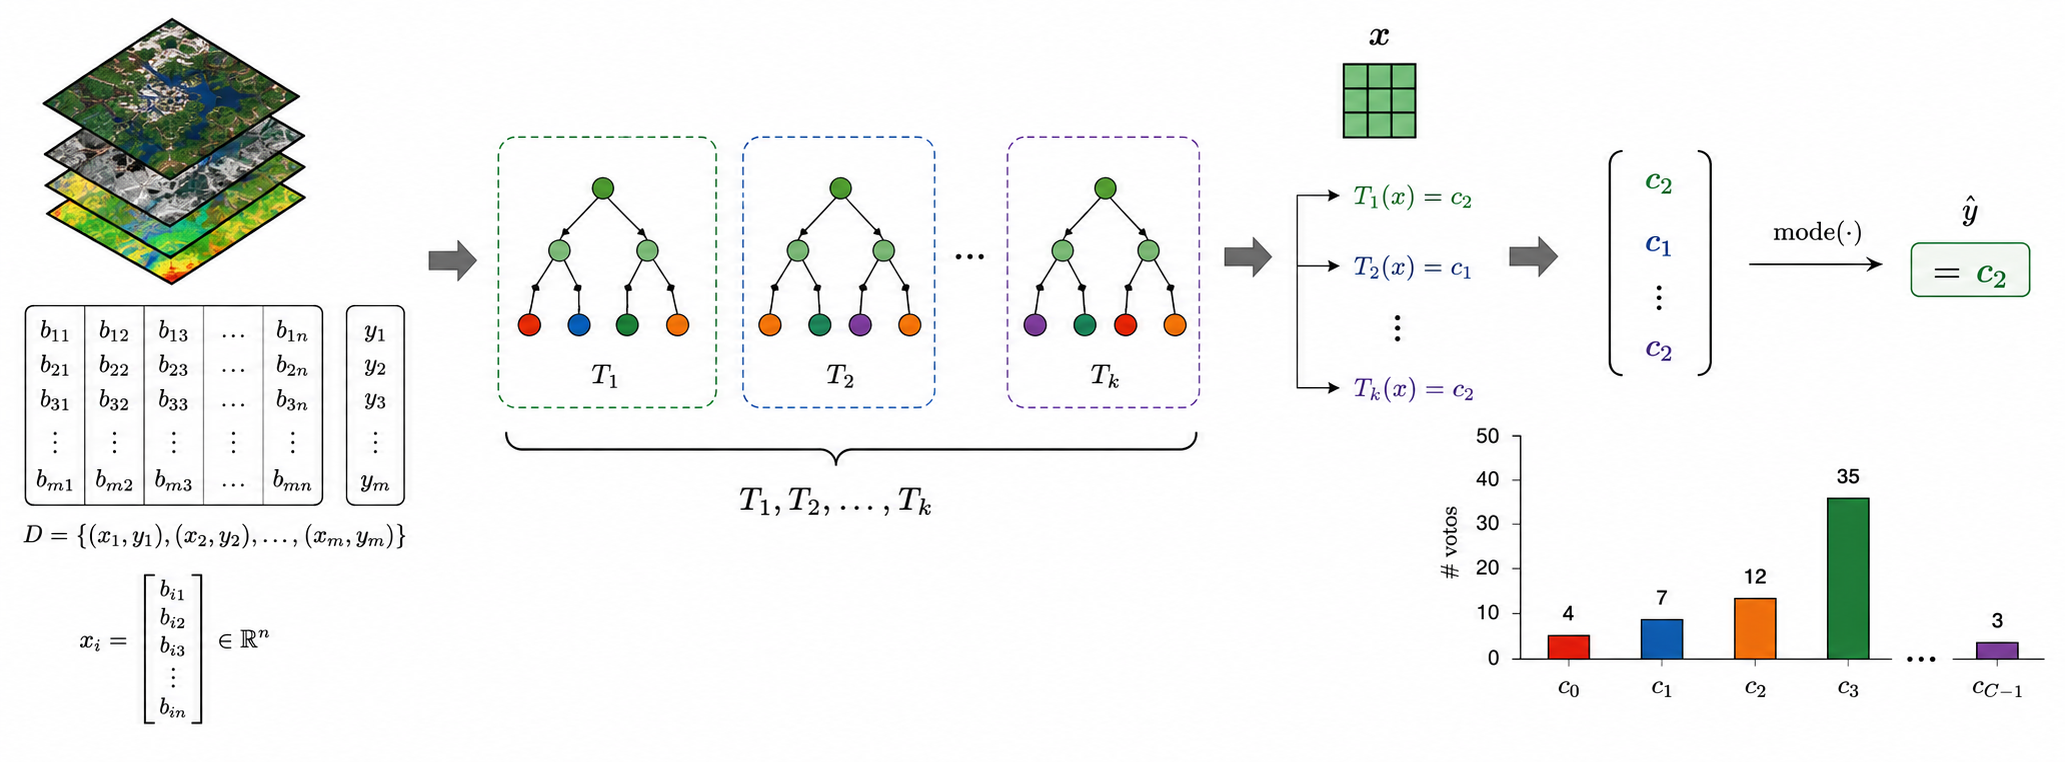

In [80]:
classifier = ee.Classifier.smileRandomForest(50).train(
    features=training,
    classProperty="class",
    inputProperties=bands_sen2
)
classified = img_sen2.classify(classifier)

In [83]:
Map = geemap.Map(basemap="CartoDB.DarkMatter", center=[40.4, -3.7], zoom=6)
class_vis = {
    "min": 0,
    "max": 3,
    "palette": [
        "#b15928",  # 0 Urban
        "#0000FF",  # 1 Water
        "#D2B48C",  # 2 Bareland
        "#33a02c",  # 3 Vegetation
    ],
}

Map.centerObject(geometry, 12)
Map.addLayer(classified, class_vis, "Random Forest Classification")
Map

Map(center=[40.67532124163311, -4.6983843725096985], controls=(WidgetControl(options=['position', 'transparent…